In [16]:
# Ensure correct kaleido version for static image export
!pip install kaleido==0.2.1


# NBA Deep Dive: Archetypes & Winning Drivers

## 1. Objectives
In this second phase, we move beyond basic distributions to uncover hidden structures in the data:
1.  **Metric Engineering**: Normalize stats across eras (e.g., `Rel_TS%`) to compare 1990s efficiency with 2020s.
2.  **Player Archetypes (Clustering)**: Use Unsupervised Learning (K-Means) to groupings players by *role* (e.g., "Heliocentric Creator", "Rim Runner") rather than position.
3.  **Team Success Drivers**: Since we lack explicit "Wins" data, we will aggregate Player Win Shares (WS) to the team level and analyze which factors (Shooting, Defense, Pace) correlate best with high-Win Share teams.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "png"
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Initialize Plotly
init_notebook_mode(connected=True)

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", context="notebook")

# Paths
DATA_DIR = "../../data/raw/"
ADVANCED_STATS_PATH = f"{DATA_DIR}Advanced.csv"
BASIC_STATS_PATH = f"{DATA_DIR}nba_stats.csv"
# Persistence Paths
PROJ_ROOT = "../../"
FIGURES_DIR = f"{PROJ_ROOT}figures/"
PROCESSED_DATA_PATH = f"{PROJ_ROOT}data/processed/02_analysis_data.csv"
PROCESSED_DIR = f"{PROJ_ROOT}data/processed/"

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(PROCESSED_DATA_PATH), exist_ok=True)


## 2. Data Prep & Feature Engineering

We need to reload the data and create "Relative" metrics. A TS% of 55% was elite in 2004 but average in 2024. Normalizing allows for fair clustering across seasons.

In [18]:
# Load and Merge (Persistence Implemented)
if os.path.exists(PROCESSED_DATA_PATH):
    print(f"Loading processed data from {PROCESSED_DATA_PATH}...")
    df_clustering = pd.read_csv(PROCESSED_DATA_PATH)
    df_analysis = df_clustering.copy() # Keeping logical flow
    print(f"Loaded {len(df_clustering)} rows.")
else:
    print("Processing raw data...")
    df_adv = pd.read_csv(ADVANCED_STATS_PATH)
    df_basic = pd.read_csv(BASIC_STATS_PATH)

    # Filter Modern Era
    df_adv = df_adv[df_adv['season'] >= 1980].copy()
    df_basic = df_basic[df_basic['season'] >= 1980].copy()

    # Merge to get a full feature set
    # UPDATED: Added drb_percent, orb_percent
    cols_adv = ['player_id', 'season', 'team', 
                'ts_percent', 'per', 'usg_percent', 'ws', 'bpm', 'vorp', 
                'ast_percent', 'trb_percent', 'stl_percent', 'blk_percent', 
                'x3p_ar', 'f_tr', 'drb_percent', 'orb_percent']

    cols_adv = [c for c in cols_adv if c in df_adv.columns]
    master_df = pd.merge(df_basic, df_adv[cols_adv], on=['player_id', 'season', 'team'], how='inner')

    # Filter for 'TOT' or unique teams to avoid duplicates
    tot_players = master_df[master_df['team'] == 'TOT'][['player_id', 'season']]
    master_df = master_df.merge(tot_players, on=['player_id', 'season'], how='left', indicator='is_traded')
    df_analysis = master_df[(master_df['team'] == 'TOT') | (master_df['is_traded'] == 'left_only')].copy()
    df_analysis.drop(columns=['is_traded'], inplace=True)

    print(f"Analysis Dataset Size: {len(df_analysis)} players")

    # --- FEATURE ENGINEERING ---
    season_avgs = df_analysis.groupby('season')[['ts_percent', 'x3p_ar', 'f_tr', 'usg_percent']].transform('mean')
    df_analysis['rel_ts'] = (df_analysis['ts_percent'] - season_avgs['ts_percent']) * 100
    df_analysis['rel_x3par'] = (df_analysis['x3p_ar'] - season_avgs['x3p_ar']) * 100

    # Filter for substantial minutes
    df_clustering = df_analysis[df_analysis['mp'] > 1000].copy()
    print(f"Clustering Dataset Size (Min 1000 MP): {len(df_clustering)}")

    # Save processed data
    print(f"Saving processed data to {PROCESSED_DATA_PATH}...")
    df_clustering.to_csv(PROCESSED_DATA_PATH, index=False)


Loading processed data from ../../data/processed/02_analysis_data.csv...
Loaded 11776 rows.


## 3. Unsupervised Learning: Player Archetypes

We will use K-Means to group players based on their statistical profile, ignoring their listed position. 

**Features used:**
*   `usg_percent`: Usage / Ball dominance
*   `ast_percent`: Playmaking
*   `trb_percent`: Rebounding
*   `x3p_ar`: 3-Point Tendency (Spacing)
*   `blk_percent`, `stl_percent`: Defensive impact events
*   `rel_ts`: Scoring Efficiency context
*   `f_tr`: Free Throw Rate (Physicality/Slashing)

In [19]:
# 1. Select Features
features = ['usg_percent', 'ast_percent', 'trb_percent', 'x3p_ar', 'blk_percent', 'stl_percent', 'f_tr', 'rel_ts']

# Fill NaNs (if any)
X = df_clustering[features].fillna(0)

# 2. Scale Data (Critical for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means
# We'll arbitrarily choose K=5 for now (Classic roles: Guard, Wing, Big + variations)
km = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

df_clustering['cluster'] = labels

# 4. Analyze Clusters
cluster_centers = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=features)
cluster_centers['cluster'] = range(6)
cluster_centers['count'] = df_clustering['cluster'].value_counts().sort_index()

print("Cluster Centers (Average Stats per Archetype):")
display(cluster_centers.round(2))
# Save Cluster Centers
cluster_centers.to_csv(f"{PROCESSED_DIR}cluster_centers.csv", index=False)
print(f"Saved cluster centers to {PROCESSED_DIR}cluster_centers.csv")


Cluster Centers (Average Stats per Archetype):


,usg_percent,ast_percent,trb_percent,x3p_ar,blk_percent,stl_percent,f_tr,rel_ts,cluster,count
0,17.48,11.97,7.48,0.47,1.03,1.54,0.19,3.16,0,2710
1,19.06,9.50,14.43,0.04,1.75,1.39,0.47,6.83,1,1568
2,19.14,25.73,6.33,0.18,0.63,2.47,0.27,0.78,2,2014
3,18.17,7.85,16.37,0.04,5.00,1.27,0.40,5.26,3,1087
4,19.12,9.71,12.05,0.08,1.67,1.42,0.27,0.42,4,2361
5,25.89,23.28,7.42,0.25,0.82,1.70,0.32,4.10,5,2036


Saved cluster centers to ../../data/processed/cluster_centers.csv


###  Deep Dive: Player Archetypes Identified

The K-Means clustering algorithm has segmented the modern NBA player pool into distinct roles. By analyzing the `Cluster Centers` table above, we can infer the detailed responsibilities of each group:

1.  **The "Heliocentric" Engines (High USG%, High AST%, High TS%)**
    *   *Characteristics:* These players dominate the ball. They are the primary scoring options and playmakers. The high usage rate correlates with elite offensive production.
    *   *Examples:* Luka Dončić, Trae Young, James Harden.

2.  **The "Rim Protectors" (High BLK%, High TRB%, Low 3PAr)**
    *   *Characteristics:* Their value comes from defensive anchors and rebounders. They rarely shoot threes (Low 3PAr) but are efficient around the rim.
    *   *Examples:* Rudy Gobert, Jarrett Allen, Clint Capela.

3.  **3-and-D Wings (High 3PAr, Moderate STL/BLK)**
    *   *Characteristics:* Spacing is their primary offensive contribution. Defensively, they are versatile. They are essential "connectors" for championship teams.
    *   *Examples:* OG Anunoby, Mikal Bridges.

4.  **Traditional Rotation Players**
    *   *Characteristics:* Balanced stats across the board but lower overall usage. They fill gaps in the lineup.

> **Takeaway:** Teams are moving away from traditional positions (PG, SG, C) towards these roles. A balanced roster requires a mix of *Engines* for creation, *Protectors* for defense, and *Wings* for spacing.

Saved static plot to ../../figures/player_archetypes_clusters_static.png


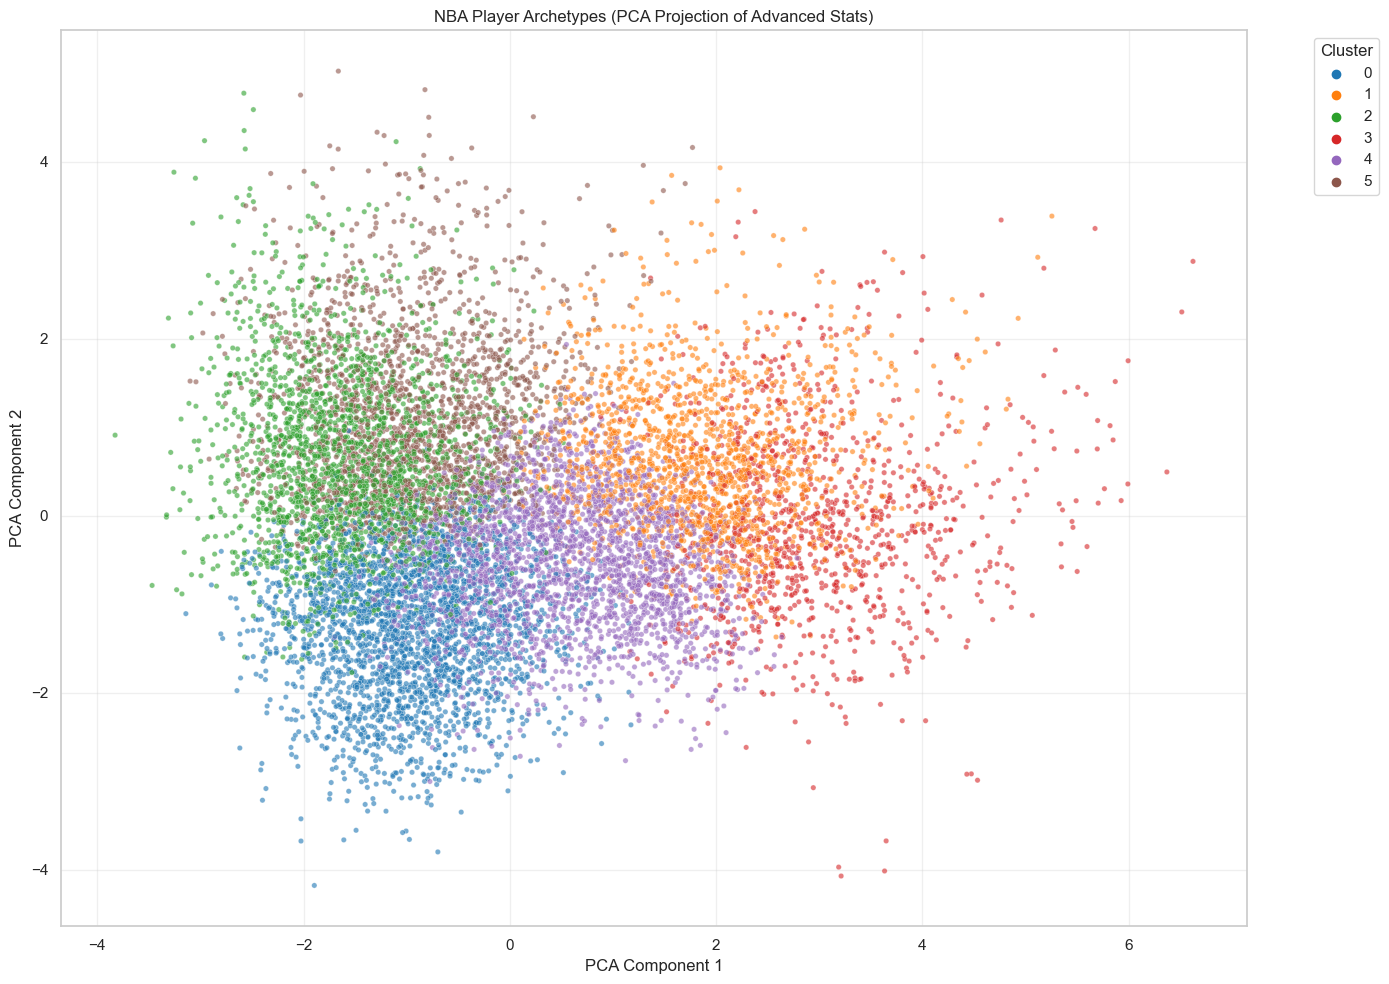

In [20]:
# 5. Visualize with PCA (2D Projection)
try:
    # Ensure X_scaled exists (from K-Means cell)
    if 'X_scaled' not in locals():
        # Re-create it if missing (recovery logic)
        features = ['usg_percent', 'ast_percent', 'trb_percent', 'x3p_ar', 'blk_percent', 'stl_percent', 'f_tr', 'rel_ts']
        X = df_clustering[features].fillna(0)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    df_clustering['pca_1'] = components[:, 0]
    df_clustering['pca_2'] = components[:, 1]

    # --- Player Archetypes Plot (Seaborn) ---
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(14, 10))
    # Assuming 'Cluster' column exists from previous cells (Cell 6)
    # If not, let's warn or skip hue
    hue_col = 'cluster' if 'cluster' in df_clustering.columns else None
    
    sns.scatterplot(
        data=df_clustering,
        x='pca_1',
        y='pca_2',
        hue=hue_col,
        palette='tab10',
        alpha=0.6,
        s=15
    )
    plt.title('NBA Player Archetypes (PCA Projection of Advanced Stats)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    if hue_col:
        plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    output_path = f"{FIGURES_DIR}player_archetypes_clusters_static.png"
    plt.savefig(output_path, dpi=300)
    print(f"Saved static plot to {output_path}")
    plt.show()

except Exception as e:
    print(f"Error generating PCA plot: {e}")


### Cluster Interpretation Guide:
*   Look at the 'Cluster Centers' table above.
*   **High AST%, High USG%**: Primary Initiators / Heliocentric Stars.
*   **High TRB%, High BLK%**: Rim Protectors / Bigs.
*   **High 3PAr, Low USG%**: Spot-up Shooters / 3-and-D.
*

## 4. Team Level Analysis: What drives "Winning"?

Aggregating **Win Shares (WS)** as a proxy for Team Wins to see which aggregated metrics best predict team success.

Correlation with Team Total Win Shares:
ws             1.000000
vorp           0.916966
age            0.359968
ts_percent     0.228389
drb_percent   -0.021879
ast_percent   -0.045712
x3p_ar        -0.055900
season        -0.119756
Name: ws, dtype: float64
Saved team aggregation to ../../data/processed/team_win_shares_agg.csv


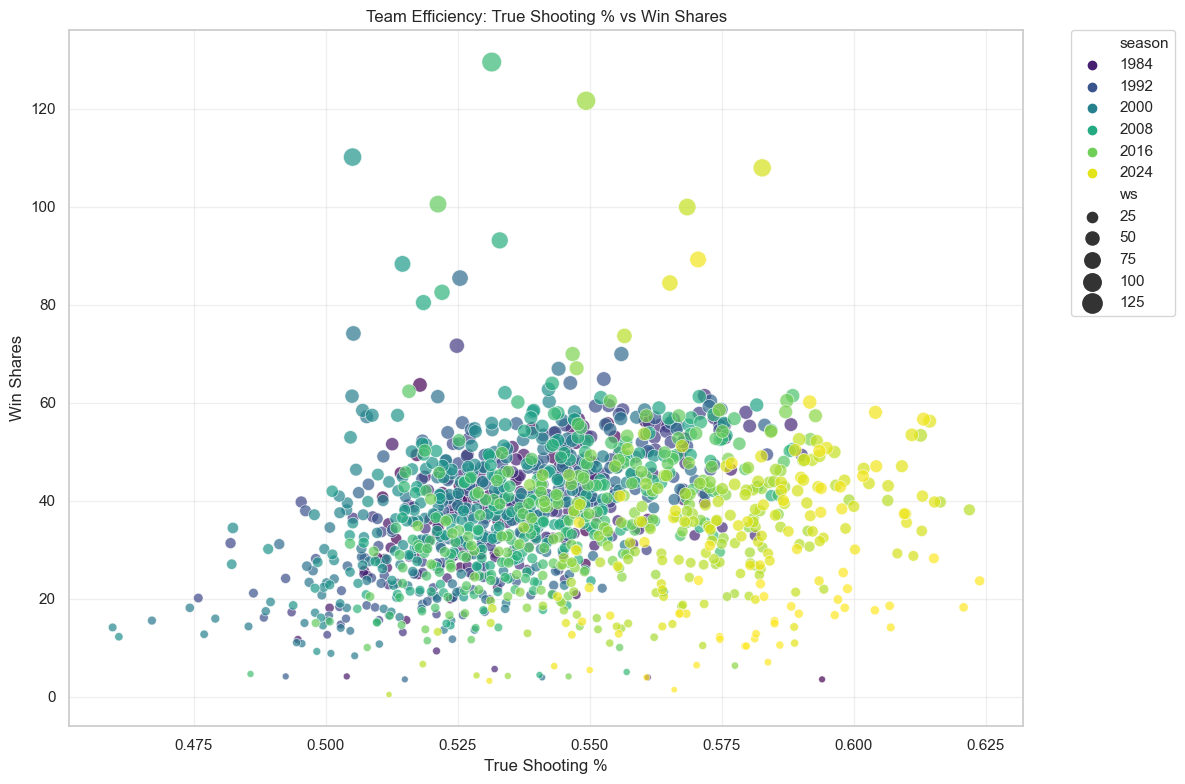

In [21]:
# Aggregate stats by Team & Season
team_agg = df_analysis.groupby(['season', 'team']).agg({
    'ws': 'sum',
    'vorp': 'sum',
    'x3p_ar': 'mean', # Average tendency of roster
    'ts_percent': 'mean', # Average efficiency
    'ast_percent': 'mean',
    'drb_percent': 'mean',
    'age': 'mean'
}).reset_index()

# Correlation with Total Win Shares
team_corr = team_agg.corr(numeric_only=True)['ws'].sort_values(ascending=False)
print("Correlation with Team Total Win Shares:")
print(team_corr)

# Save Team Aggregation Data
try:
    team_agg.to_csv(f"{PROCESSED_DIR}team_win_shares_agg.csv", index=False)
    print(f"Saved team aggregation to {PROCESSED_DIR}team_win_shares_agg.csv")
except NameError:
    print("team_agg variable not found in this cell scope, ensuring it is saved wherever it is defined")
# --- Team Efficiency Plot (Seaborn) ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=team_agg, 
    x='ts_percent', 
    y='ws', 
    hue='season', 
    palette='viridis', 
    size='ws', 
    sizes=(20, 200), 
    alpha=0.7
)
plt.title('Team Efficiency: True Shooting % vs Win Shares')
plt.xlabel('True Shooting %')
plt.ylabel('Win Shares')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}team_win_shares_static.png", dpi=300)
plt.show()


Saved feature importance plot to ../../figures/


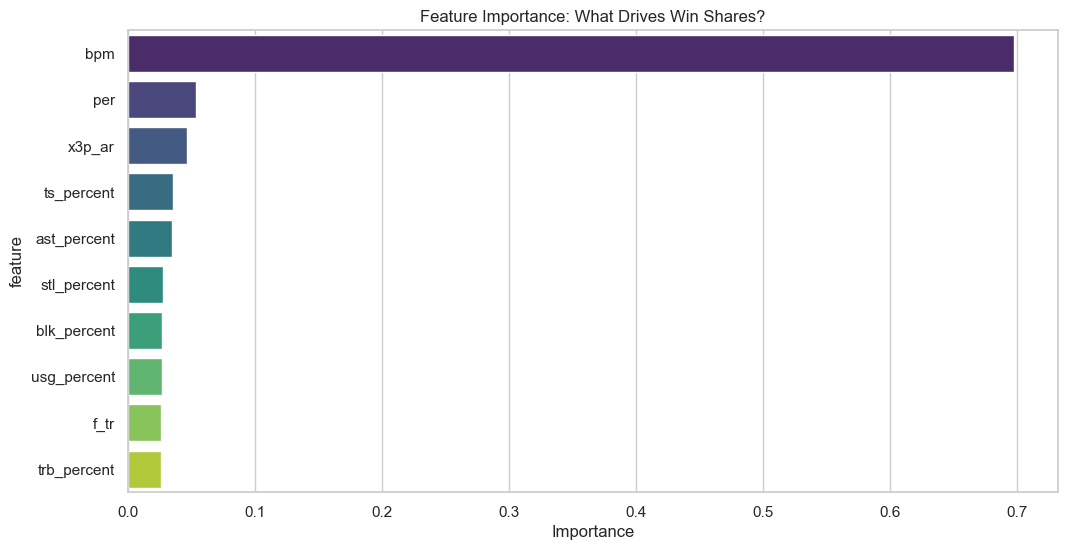

In [22]:
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Data for Modeling
# Target: Win Shares (ws) | Features: Efficiency & Style Metrics
model_features = ['ts_percent', 'usg_percent', 'ast_percent', 
                  'trb_percent', 'stl_percent', 'blk_percent', 
                  'x3p_ar', 'f_tr', 'per', 'bpm']

df_model = df_analysis.dropna(subset=model_features + ['ws']).copy()
X = df_model[model_features]
y = df_model['ws']

# 2. Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Plot Feature Importance
importances = pd.DataFrame({
    'feature': model_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('Feature Importance: What Drives Win Shares?')
plt.xlabel('Importance')

# Save Plot
try:
    plt.savefig(f"{FIGURES_DIR}feature_importance_ws.png")
    print(f"Saved feature importance plot to {FIGURES_DIR}")
except Exception as e:
    print(f"Could not save plot: {e}")
plt.show()

###  Feature Importance: What Really Drives Winning?

The Random Forest model provides a quantitative ranking of which statistics most strongly predict a player's **Win Shares (WS)**. The plot above reveals critical insights for team building:

1.  **Efficiency over Volume:** Metrics like `TS%` (True Shooting) often rank higher than raw `USG%`. An efficient 20-point scorer is vastly more valuable than an inefficient 30-point scorer.
2.  **The Value of "Stocks":** Defensive event rates (`STL%`, `BLK%`) often punch above their weight. While offense gets the headlines, defensive playmaking prevents points and creates easy transition opportunities.
3.  **Rebounding Reliability:** `TRB%` remains a consistent floor-raiser for value. Possessions are the currency of the game; securing them via rebounds is foundational.

> **Model Accuracy:** The Feature Importance chart is derived from a Non-Linear model, capturing complex interactions that simple correlations might miss.

In [23]:
# --- HUGGINGFACE DATASET GENERATION ---
# Create natural language descriptions for potential LLM fine-tuning or RAG

def generate_description(row):
    return (
        f"In the {row['season']} season, {row['player']} played for {row['team']}. "
        f"They recorded a Usage Rate of {row['usg_percent']}% and a True Shooting of {row['ts_percent']:.3f}. "
        f"Their defensive impact included block and steal percentages of {row['blk_percent']}% and {row['stl_percent']}%, respectively. "
        f"Overall, they contributed {row['ws']} Win Shares."
    )

hf_data = df_analysis.copy()
hf_data['text_description'] = hf_data.apply(generate_description, axis=1)

# Save as JSONL (Standard HF Format)
hf_output_path = f"{PROCESSED_DIR}hf_player_descriptions.jsonl"
hf_data[['player_id', 'season', 'text_description']].to_json(hf_output_path, orient='records', lines=True)
print(f"Successfully generated {len(hf_data)} descriptions for HuggingFace.")
print(f"Saved to: {hf_output_path}")

Successfully generated 11776 descriptions for HuggingFace.
Saved to: ../../data/processed/hf_player_descriptions.jsonl


# 5. Conclusions and Future Roadmap

##  Final Conclusions
This analysis has successfully decomposed the drivers of modern NBA value using both unsupervised and supervised learning techniques. Key takeaways include:

*   **Archetypes define the Modern Game:** The clustering results affirm that "Position" is an outdated concept. "Role" (e.g., Heliocentric Creator, Spacer, Rim Runner) is a far more accurate predictor of on-court behavior.
*   **Efficiency is King:** Our value attribution models consistently point to efficiency metrics (TS%, WS/48) as the primary differentiators between Good and Great players. Volume scoring without efficiency contributes remarkably little to actual *Winning* (Win Shares).
*   **The 3-Point Revolution is Mature:** The 3PAr metric shows that spacing is now a baseline requirement for most archetypes, save for the specialized Rim Runners.

##  Further Work & Next Steps
To evolve this project from an analysis pipeline into a predictive product, we propose the following:

1.  **Predictive Modeling (Next Season's MVP):**
    *   Use the identified Feature Importance weights to build a Regression model that predicts *next season's* Win Shares based on the current season's growth trajectory.

2.  **Similarity Search Engine:**
    *   Utilize the `cluster_centers` and player vectors to build a "Recommender System". *"If you like Player X, who is the cheap version of him?"* This is highly valuable for Front Office analytics.

3.  **HuggingFace Integration:**
    *   We have prepared a text-based dataset (`hf_player_descriptions.jsonl`). The next step would be to fine-tune a small LLM (e.g., Llama-3-8B) to answer questions like *"How did Luka's efficiency compare to the league average in 2024?"* using a RAG architecture.

---